In [14]:
import torch
from torch import nn, optim

## 转置卷积API

In [15]:
conv_t = nn.ConvTranspose2d(in_channels=3, out_channels=16, kernel_size=3, stride=2, padding=1, output_padding=1)

In [16]:
# 定义输入
input = torch.randn(1, 3, 128, 128)

In [17]:
output = conv_t(input)
print(output.shape)

torch.Size([1, 16, 256, 256])


## 去噪自编码器

In [18]:
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt

### 1. 准备数据

In [30]:
# 1. 加载原始图片
image = Image.open('Apple.jpg')
print(image)

<PIL.WebPImagePlugin.WebPImageFile image mode=RGB size=600x574 at 0x172B558F3B0>


In [25]:
# 定义图像转换操作(调整大小,转为tensor)
transform = T.Compose([
    T.Resize((256,256)),
    T.ToTensor()
])
# 2. 转换图片
img_tensor = transform(image)
print(img_tensor.shape)

torch.Size([3, 256, 256])


In [26]:
# 3. 转换为ndarray,方便画图
img_numpy = img_tensor.permute(1,2,0).numpy()
print(img_numpy.shape)

(256, 256, 3)


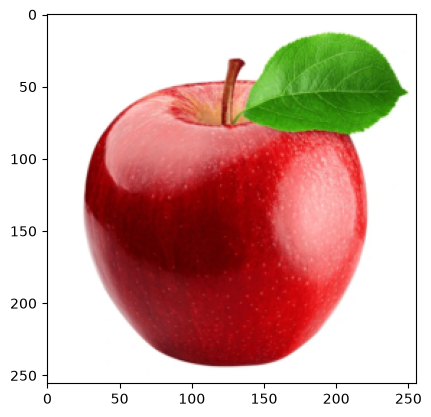

In [31]:
# 画图
plt.imshow(img_numpy)
plt.show()

In [23]:
# 4. 加入噪声得到模型输入
img_noise = img_tensor + torch.randn_like(img_tensor) * 0.2

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7329166..1.8613105].


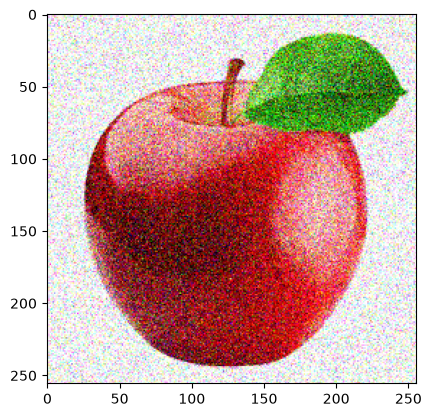

In [32]:
# 5. 将噪声图片转换为ndarray,画图
img_noise_numpy = img_noise.permute(1,2,0).numpy()
plt.imshow(img_noise_numpy)
plt.show()

### 2. 定义模型

In [40]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # 编码器
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(16, 8, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        # 解码器
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # 编码
        features = self.encoder(x)
        # print("编码输出特征形状:", features.shape)
        # 解码
        output = self.decoder(features)
        # print("解码输出特征形状:", output.shape)
        return output


In [41]:
# 测试前向传播
model = Autoencoder()
input = torch.randn(1, 3, 256, 256)
output = model(input)
print(output.shape)

torch.Size([1, 3, 256, 256])


### 3. 模型训练

In [42]:
# 定义设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(16, 3, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): Sigmoid()
  )
)

In [43]:
# 定义超参数
lr = 0.001
epochs = 500

In [44]:
# 损失函数
loss_fn = nn.MSELoss()
# 优化器
optimizer = optim.Adam(model.parameters(), lr=lr)

In [45]:
# 开始训练
for epoch in range(epochs):
    # 定义输入和目标
    input = img_noise.to(device)
    target =  img_tensor.to(device)
    # 前向传播
    output = model(input)
    # 计算损失
    loss = loss_fn(output, target)
    # 反向传播
    loss.backward()
    # 更新参数
    optimizer.step()
    # 梯度清零
    optimizer.zero_grad()
    # 每五十轮打印一次损失
    if (epoch+1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')


Epoch [50/500], Loss: 0.0884
Epoch [100/500], Loss: 0.0280
Epoch [150/500], Loss: 0.0167
Epoch [200/500], Loss: 0.0128
Epoch [250/500], Loss: 0.0093
Epoch [300/500], Loss: 0.0056
Epoch [350/500], Loss: 0.0043
Epoch [400/500], Loss: 0.0035
Epoch [450/500], Loss: 0.0030
Epoch [500/500], Loss: 0.0026


In [48]:
# 保存模型
torch.save(model.state_dict(), 'model.pth')

### 4. 模型推理

In [49]:
with torch.no_grad():
    input = img_noise.to(device)
    # 前向传播
    output = model(input)

In [50]:
print(output.shape)

torch.Size([3, 256, 256])


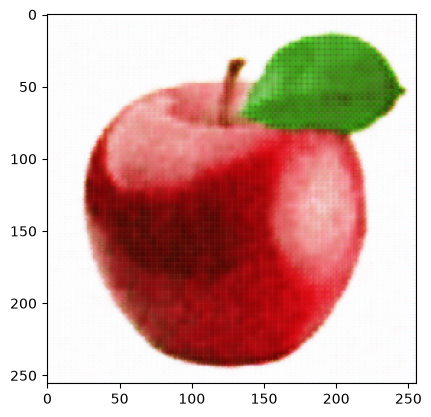

In [51]:
# 转换为ndarray
img_recon_numpy = output.permute(1,2,0).cpu().numpy()
plt.imshow(img_recon_numpy)